# Лабоаторная работа 2
## Линейная регрессия

In [1]:
import numpy as np
import pandas as pd

**1.** Загрузите датасет с успеваемостью студентов (https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression)

   Изучите признаки: их шкалу, тип данных, наличие пропусков, распределение. Нашей целевой переменной будет последняя колонка - Performance Index

In [152]:
data = pd.read_csv('Student_Performance.csv')
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [153]:
data['Extracurricular Activities'] = data['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
data.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [154]:
y = data['Performance Index'].to_numpy()
X = data[['Hours Studied', 'Previous Scores','Extracurricular Activities','Sleep Hours','Sample Question Papers Practiced']].to_numpy()
X

array([[ 7, 99,  1,  9,  1],
       [ 4, 82,  0,  4,  2],
       [ 8, 51,  1,  7,  2],
       ...,
       [ 6, 83,  1,  8,  5],
       [ 9, 97,  1,  7,  0],
       [ 7, 74,  0,  8,  1]], dtype=int64)

In [155]:
corr_matrix = np.corrcoef(data, rowvar=False)
print(corr_matrix)

[[ 1.         -0.01238992  0.00387254  0.0012452   0.01746317  0.37373035]
 [-0.01238992  1.          0.00836932  0.00594422  0.00788803  0.91518914]
 [ 0.00387254  0.00836932  1.         -0.02328364  0.01310278  0.02452495]
 [ 0.0012452   0.00594422 -0.02328364  1.          0.00399022  0.04810584]
 [ 0.01746317  0.00788803  0.01310278  0.00399022  1.          0.04326833]
 [ 0.37373035  0.91518914  0.02452495  0.04810584  0.04326833  1.        ]]


Переведите все фичи в числа и сохраните в переменной Х формата np.array. Целевую колонку сохраните в массив y. Для превращения в массив можно использовать df.values. Постройте корреляционную матрицу (это можно сделать как за счет numpy, так и с исходным датафреймом, если выделить из него только числовые колонки)

Разбейте данные на тренировочный и тестовый наборы в отношении 80:20

In [10]:
from sklearn.model_selection import train_test_split

In [156]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(8000, 5) (2000, 5)


**2.** На основе базовых классов из sklearn напишите свою линейную регрессию, где коэффициенты находятся с помощью псевдообратной матрицы. Не забудьте про свободный член! Он должен откуда-то появиться.
   $$ w = (X^TX)^{-1} X^T y$$

Второй регрессор напишите с градиентным спуском (мы тут не будем рассматривать стохастический и мини-батч, хотя, если интересно, можете и их заимплементить). Подумайте, как вы будете решать, когда должен остановиться градиентный спуск. По результатам измышлений допишите еще входных параметров в метод \__init__. В качестве функции потерь выберем MSE. В матричной записи она будет выглядеть как $\frac{1}{N}(Xw - y)^T(Xw - y).$ Дифференцируя ее по $w$, получим $$\frac{2}{N} X^T(Xw - y).$$ Формула с псевдообратной матрицей, кстати, получается, если приравнять это к 0 и выразить $w$.

Мы хотим двигаться в направлении, противоположном этому, т.е. эта величина, умноженная на скорость обучения (learning rate), отнимается от текущих весов. Коэффициент 2 из нее поэтому можно и убрать, он войдет в lr, а вот убирать $N$, пожалуй, не стоит.

In [13]:
from sklearn.base import BaseEstimator, RegressorMixin

In [20]:
class PseudoInvRegressor(BaseEstimator, RegressorMixin):
    def __init__(self):
        self.w = None   
        self.c = None  

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        # w = (X^T X)^(-1) X^T y
        w = np.linalg.pinv(X_bias.T @ X_bias) @ X_bias.T @ y
        
        self.c = w[0, 0]
        self.w = w[1:, :].flatten()

        return self

    def predict(self, X):
        X = np.asarray(X)
        return X @ self.w + self.c

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin

class GradRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, lr=0.001, eps=1e-6, max_iter=100000):
        self.lr = lr
        self.max_iter = max_iter
        self.eps = eps
        self.w = None
        self.c = None
        
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1, 1)


        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        self.w_full = np.random.randn(X_bias.shape[1], 1) * 0.01  
        prev_loss = float("inf")

        n = len(y)

        for _ in range(self.max_iter):
            preds = X_bias @ self.w_full
            loss = np.mean((preds - y)**2)

            if abs(prev_loss - loss) < self.eps:
                break

            prev_loss = loss

            gradient = X_bias.T @ (preds - y) / n
            gradient = np.clip(gradient, -1e3, 1e3) 
            self.w_full -= self.lr * gradient

        self.c = float(self.w_full[0, 0])
        self.w = self.w_full[1:, :]

        return self
        
    def predict(self, X):
        X = np.asarray(X)
        return (X @ self.w + self.c).flatten()


In [16]:
from sklearn.metrics import mean_squared_error

In [67]:
def grid_experiment(X_train, y_train, X_val, y_val, lrs, eps_list):
    results = np.zeros((len(lrs), len(eps_list)))
    
    for i, lr in enumerate(lrs):
        for j, eps in enumerate(eps_list):
            model = GradRegressor(lr=lr, eps=eps, max_iter=200000)  
            model.fit(X_train, y_train)
            preds = model.predict(X_val)

            mse = mean_squared_error(y_val, preds)
            if np.isnan(mse):
                mse = np.inf
                
            results[i, j] = mse

    return results


In [68]:
lrs = np.logspace(-6, -2, 5)        
eps_list = np.logspace(-8, -3, 6)   

results = grid_experiment(X_train, y_train, X_test, y_test, lrs, eps_list)

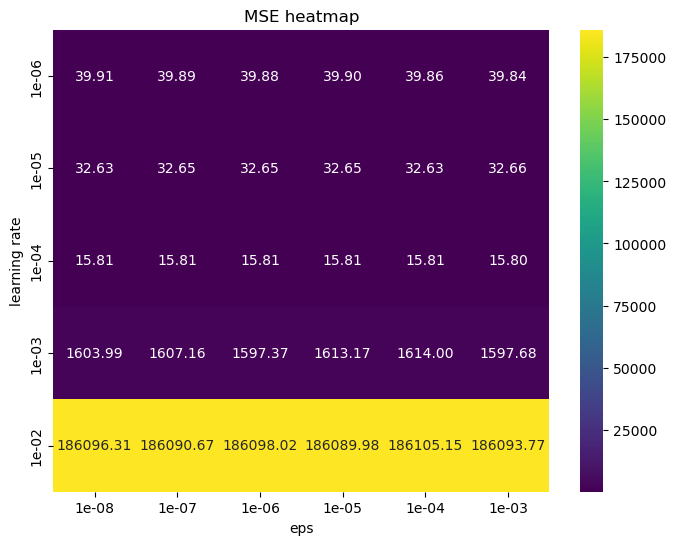

In [74]:
import matplotlib.pyplot as plt  
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    results,
    annot=True,        
    fmt=".2f",         
    cmap="viridis",  
    xticklabels=[f"{e:.0e}" for e in eps_list],
    yticklabels=[f"{lr:.0e}" for lr in lrs]
)

plt.xlabel("eps")
plt.ylabel("learning rate")
plt.title("MSE heatmap")
plt.show()

In [70]:
model = PseudoInvRegressor()  
model.fit(X_train, y_train)
preds = model.predict(X_test)

mse = mean_squared_error(y_test, preds)
mse

4.082628398526094

Обучите оба регрессора на загруженных данных. Для второго регрессора придется поэкспериментировать со скоростью и продолжительностью обучения. Постройте график ошибок. 

**3.** Попробуйте нормализовать или стандартизировать данные, и повторите попытку для обоих регрессоров. Для этого воспользуйтесь скейлерами из sklearn. Метод fit_transform позволяет сразу и настроить параметры скейлера и выполнить масштабирование. **Внимание!** Обучать (fit) скейлер нужно только на тренировочных данных. А потом с полученными на них параметрами применять его к тестовым. **Еще внимание!** Если в вашей матрице $X$ был столбик для свободного члена, после масштабирования он станет нулевым. Это не то, чего нам бы хотелось, это надо пофиксить

Итак, что изменилось?

Контрольные вопросы: зачем масштабировать данные? Когда это обязательно, когда не очень? Надо ли масштабировать $y$? Зачем градиентный регрессор (а он имплементирован не только вами, но и авторами sklearn), если можно найти псевдообратную матрицу, которая является оптимальным решением?

In [ ]:
# на ваш выбор
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [160]:
scaler = MinMaxScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [77]:
model = PseudoInvRegressor()  
model.fit(X_train, y_train)
preds = model.predict(X_test)

mse = mean_squared_error(y_test, preds)
mse

4.082628398521854

In [ ]:
lrs = [1e-04]     
eps_list = [1e-03]

results = grid_experiment(X_train, y_train, X_test, y_test, lrs, eps_list)
results

array([[14.29730327]])

**4.** Добавим возможность l1 и l2 регуляризации. Это означает, что функция потерь примет вид

$$\frac{1}{N}\sum_{i=1}^N (y_i - X_iw)^2 + \lambda_1\sum_{j=1}^m |w_j| + \lambda_2\sum_{j=1}^m w_j^2,$$

где $\lambda_1$, $\lambda_2$ отвечают за выраженность l1 и l2 регуляризаций и могут их выключить, будучи равными 0.

Здесь мы сталкиваемся с проблемой в случае псевдообратного решения - из-за того, что модуль недифференцируем в 0, мы, вообще-то, не можем получить одну конечную формулу для решения. Но для l2 все в порядке. 

Итак, для **псевдообратного регрессора** выведите новую формулу с учетом l2-регуляризации. Выводится она из тех соображений, что искомое $w$ - это точка, где достигается экстремум функции потерь, т.е. равна 0 ее производная. Добавьте в класс этого регрессора l2-регуляризацию.

Для **градиентного регрессора** добавьте обе регуляризации (производной модуля будем считать $sgn$).

In [83]:
class PseudoInvRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, l):
        self.w = None   
        self.c = None
        self.lamda = l  

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        w = np.linalg.pinv(X_bias.T @ X_bias + self.lamda * np.eye(X_bias.shape[1])) @ X_bias.T @ y
        
        self.c = w[0, 0]
        self.w = w[1:, :].flatten()

        return self

    def predict(self, X):
        X = np.asarray(X)
        return X @ self.w + self.c


In [86]:
mse_list = []

for l in np.arange(0.0, 1.0, 0.1):
    model = PseudoInvRegressor(l)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse_list.append(mean_squared_error(y_test, pred))

print(mse_list)
min(mse_list)

[4.082628398521854, 4.0831789113684, 4.083740803013842, 4.084314061009548, 4.084898672922562, 4.085494626335383, 4.086101908846153, 4.086720508068415, 4.087350411631263, 4.087991607179226]


4.082628398521854

In [211]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin

class GradRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, lr=1e-3, eps=1e-4, max_iter=1000, l1=0.0, l2=0.0):
        self.lr = lr
        self.eps = eps
        self.max_iter = max_iter
        self.l1 = l1
        self.l2 = l2
        self.w = None
        self.c = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1, 1)
        n_samples, n_features = X.shape

        X_bias = np.hstack([np.ones((n_samples, 1)), X])
        self.w_full = np.random.randn(n_features + 1, 1) * 0.01
        prev_loss = float("inf")

        for i in range(self.max_iter):
            preds = X_bias @ self.w_full
            mse_loss = np.mean((preds - y) ** 2)
            l1_loss = self.l1 * np.sum(np.abs(self.w_full[1:]))
            l2_loss = self.l2 * np.sum(self.w_full[1:] ** 2)
            loss = mse_loss + l1_loss + l2_loss

            if abs(prev_loss - loss) < self.eps:
                break
            prev_loss = loss

            gradient = (2 / n_samples) * X_bias.T @ (preds - y)
            gradient[1:] += self.l1 * np.sign(self.w_full[1:]) + 2 * self.l2 * self.w_full[1:]

            self.w_full -= self.lr * gradient

        self.c = float(self.w_full[0])
        self.w = self.w_full[1:]

        return self

    def predict(self, X):
        X = np.asarray(X)
        return (X @ self.w + self.c).flatten()


In [212]:
model_l1 = GradRegressor(l1=1)
model_l2 = GradRegressor(l2=1)

model_l1.fit(X_train, y_train)
model_l2.fit(X_train, y_train)
    
pred1 = model_l1.predict(X_test)
pred2 = model_l2.predict(X_test)
myl1_mse = mean_squared_error(y_test, pred1)
myl2_mse = mean_squared_error(y_test, pred2)

print(myl1_mse)
print(myl2_mse)

181.72827435705906
302.36663528259214


C:\Users\bakru_b9pmn2k\AppData\Local\Temp\ipykernel_11096\2758131555.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.c = float(self.w_full[0])


**5.** Обучите ваши регрессоры с этими новыми настройками. Рассмотрите 3 случая: 
- псевдообратные регрессор с l2
- градиентный регрессор с l1
- градиентный регрессор с l2

Подберите какие-то лямбды, дающие адекватный результат. Потом загрузите регрессоры из sklearn и обучите их с теми же (насколько это возможно) настройками. Сравните полученные веса и ошибку на тренировочном и тестовых множествах (выведите их куда-нибудь в одно место, вместе с параметрами, чтоб красиво. Можно, например, собрать из них маленький датафрейм)

Когда пойдете читать справку для Lasso и Ridge, обратите внимание на описываемые способы решения: в Ridge(l2) есть несколько опций, в том числе детерминированных; в Lasso(l1) используется координатный спуск.

Контрольный вопрос: почему про L1 говорят, что он отбирает признаки, а L2 - нет?

In [92]:
from sklearn.linear_model import Lasso, Ridge

In [ ]:
lr = 0.0001       
max_iter = 100000
eps = 1e-4

lasso_model = Lasso(alpha=0.1, max_iter=max_iter, tol=eps, fit_intercept=True)
ridge_model = Ridge(alpha=0.1, max_iter=max_iter, tol=eps, fit_intercept=True)

lasso_model.fit(X_train, y_train)
pred1 = lasso_model.predict(X_test)
mse_Lasso = mean_squared_error(y_test, pred1)

ridge_model.fit(X_train, y_train)
pred2 = ridge_model.predict(X_test)
mse_Ridge = mean_squared_error(y_test, pred2)

In [198]:
res = pd.DataFrame({
    "Model": ["GradRegressor_L1", "GradRegressor_L2", "Lasso", "Ridge"],
    "Min_MSE": [myl1_mse, myl2_mse, mse_Lasso, mse_Ridge],
    "lamda": [1, 1, 0, 0]
})

res

,Model,Min_MSE,lamda
0,GradRegressor_L1,4.259959,1
1,GradRegressor_L2,107.698684,1
2,Lasso,4.660800,0
3,Ridge,4.083298,0


**6.** Почитайте справку для класса SGDRegressor и сообразите, как сделать так, чтобы он оптимизировал MAE, а не MSE. Обучите два регрессора - один с абсолютной ошибкой, другой с квадратичной. Сравните веса, значения обеих ошибок на тренировочном и тестовом наборах

**7.** В датасете со студентами у нас был нормально распределенный таргет. Вообще-то это как бы не обязательно (нормальному распределению должны следовать ошибки; да и это тоже необязательно - смотря какие выводы вы хотите потом сделать о модели), но в некоторых туториалах можно встретить и такое требование. А еще в некоторых - требование нормального распределения фичей. Математического пояснения этому обычно не дается, а говорится что-то вроде "модель эффективнее обучается на нормально распределенных данных". 

Загрузите датасет с ценами медстраховки (https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset ). Масштабируйте данные, предобработайте категориальные признаки. Попробуйте скорректировать а) распределение целевой переменной б) распределения не бинарных фичей до нормального. На этих данных обучите модели настолько хорошо, насколько сможете, и сравните их качество с моделями без подобных преобразований. Сравнивать будем по MSE на тесте (20%), при этом если вы преобразовали целевую переменную, не забудьте преобразовать ее обратно прежде чем вычислять эту MSE для сравнения

**Внимание!** Корректировка распределения проводится по тренировочным данным. По ним вы определяете некое преобразование, которое потом будет применяться на тест

**8.** Добавим в наши данные немного мусора. Сделайте колонку с id пациента (числа от 0 до ...) и его любимым цветом (случайный цвет, заданный тремя параметрами RGB, распределение случайных величин - на ваше усмотрение). Проведите предобработку данных, которую посчитаете нужной, только не выбрасывайте наши мусорные колонки. Чтобы поменьше заниматься подбором параметров, обучим следующием модели:

- псевдообратный регрессор
- псевдообратный регрессор с L2 регуляризацией
- псевдообратный регрессор, но мы выбросили id
- псевдообратный регрессор с L2 регуляризацией, но мы выбросили id
- псевдообратный регрессов, но мы выбросили и id, и цвета
- псевдообратный регрессор с L2 регуляризацией, но мы выбросили и id, и цвета

Вычислите для каждой модели $R^2$ и скорректированный $R^2$ на тестовом и на тренировочном множествах, сведите в табличку. Какие выводы можно сделать из увиденного? 